<a href="https://colab.research.google.com/github/anix07/MES_PoC-forcasting.ipynb/blob/main/MES_PoC_forcasting.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#INSTALLING GRAPHVIZ

In [ ]:
!apt-get install -y graphviz > /dev/null
!pip install graphviz --quiet
print('Graphviz installed successfully')

Graphviz installed successfully


#BUILDING THE DIAGRAM

In [ ]:
from graphviz import Digraph

g = Digraph('MES_Architecture', format='png')
g.attr(rankdir='TB', splines='ortho', nodesep='0.4', ranksep='0.6',
       fontname='Arial', fontsize='12', bgcolor='white', pad='0.4')
g.attr('node', fontname='Arial', fontsize='10', style='filled', shape='box')
g.attr('edge', fontname='Arial', fontsize='9', color='#555555')

# Colour palette
src_fill = '#FFE2B7'
ing_fill = '#FFC8A2'
str_fill = '#FFB199'
sto_fill = '#A8D8B9'
pro_fill = '#7FB3D5'
ser_fill = '#BB8FCE'
sec_fill = '#F1948A'
gov_fill = '#F7DC6F'

# Layer 1: Data Sources
with g.subgraph(name='cluster_sources') as c:
    c.attr(label='1. Data Sources', style='rounded,filled', fillcolor='#FFF6E5',
           color='#E8C56C', fontsize='11', fontname='Arial', labelloc='t')
    c.node('sm', 'Smart Meters\n(time-series)', fillcolor=src_fill)
    c.node('ev', 'EV Chargers\n(events)', fillcolor=src_fill)
    c.node('solar', 'Solar Panels\n(telemetry)', fillcolor=src_fill)
    c.node('iot', 'Substation IoT\n(real-time)', fillcolor=src_fill)
    c.node('cust', 'Billing & CRM\n(batch)', fillcolor=src_fill)
    c.node('wx', 'Weather Feeds\n(API)', fillcolor=src_fill)

# Layer 2: Ingestion
with g.subgraph(name='cluster_ingest') as c:
    c.attr(label='2. Ingestion', style='rounded,filled', fillcolor='#FFEEDC',
           color='#E89B65', fontsize='11', fontname='Arial', labelloc='t')
    c.node('mqtt', 'IoT Gateway\n(MQTT / HTTPS)', fillcolor=ing_fill)
    c.node('api', 'REST API\nGateway', fillcolor=ing_fill)
    c.node('batch_ing', 'Batch Loader\n(SFTP / JDBC)', fillcolor=ing_fill)

# Layer 3: Streaming Backbone
with g.subgraph(name='cluster_bus') as c:
    c.attr(label='3. Streaming Backbone', style='rounded,filled', fillcolor='#FFE0D9',
           color='#D77559', fontsize='11', fontname='Arial', labelloc='t')
    c.node('kafka', 'Distributed Event Log\n(Kafka-style pub/sub)',
           fillcolor=str_fill, shape='cylinder')

# Layer 4: Lakehouse Storage
with g.subgraph(name='cluster_store') as c:
    c.attr(label='4. Lakehouse Storage (Object Store + Delta/Iceberg)',
           style='rounded,filled', fillcolor='#E1F0E5',
           color='#7DAE8E', fontsize='11', fontname='Arial', labelloc='t')
    c.node('bronze', 'Bronze\nRaw / Immutable', fillcolor=sto_fill)
    c.node('silver', 'Silver\nCleaned / Conformed', fillcolor=sto_fill)
    c.node('gold', 'Gold\nCurated / Aggregated', fillcolor=sto_fill)
    c.edge('bronze', 'silver', style='dashed')
    c.edge('silver', 'gold', style='dashed')

# Layer 5: Processing
with g.subgraph(name='cluster_proc') as c:
    c.attr(label='5. Processing', style='rounded,filled', fillcolor='#D9E7F3',
           color='#5A8CB5', fontsize='11', fontname='Arial', labelloc='t')
    c.node('stream', 'Stream Processor\n(real-time)', fillcolor=pro_fill)
    c.node('batch', 'Batch Processor\n(Spark / SQL)', fillcolor=pro_fill)
    c.node('ml', 'ML Platform\n(forecast / anomaly)', fillcolor=pro_fill)

# Layer 6: Serving
with g.subgraph(name='cluster_serve') as c:
    c.attr(label='6. Serving', style='rounded,filled', fillcolor='#EFE0F2',
           color='#9B70AC', fontsize='11', fontname='Arial', labelloc='t')
    c.node('dwh', 'SQL Warehouse\n(BI queries)', fillcolor=ser_fill)
    c.node('dash', 'Dashboards\n(grid monitoring)', fillcolor=ser_fill)
    c.node('apis', 'Forecast & Alert\nAPIs', fillcolor=ser_fill)

# Cross-cutting Concerns
with g.subgraph(name='cluster_xc') as c:
    c.attr(label='Cross-cutting Concerns', style='rounded,filled',
           fillcolor='#FFF4F2', color='#D4564A', fontsize='11',
           fontname='Arial', labelloc='t')
    c.node('sec', 'Security\n• KMS encryption (in transit & at rest)\n'
                  '• IAM / RBAC  • Private network  • Key rotation',
           fillcolor=sec_fill)
    c.node('gov', 'Governance & Observability\n'
                  '• Data catalog & lineage  • Schema registry\n'
                  '• Metrics, logs, traces  • Audit trail (GDPR / Ofgem)',
           fillcolor=gov_fill)
    c.node('dr', 'Backup & Disaster Recovery\n'
                 '• Cross-region replication  • Point-in-time recovery\n'
                 '• Tested RTO / RPO  • Immutable backup snapshots',
           fillcolor='#85C1E9')

# Arrows — Sources to Ingestion
for n in ('sm', 'ev', 'solar', 'iot'):
    g.edge(n, 'mqtt')
g.edge('cust', 'api')
g.edge('wx', 'api')
g.edge('cust', 'batch_ing')

# Arrows — Ingestion to Streaming / Bronze
g.edge('mqtt', 'kafka')
g.edge('api', 'kafka')
g.edge('batch_ing', 'bronze', label='bulk')

# Arrows — Streaming to Bronze / Stream processing
g.edge('kafka', 'bronze', label='land')
g.edge('kafka', 'stream', label='real-time')

# Arrows — Storage to Processing
g.edge('silver', 'batch')
g.edge('gold', 'ml')
g.edge('gold', 'dwh')

# Arrows — Processing to Gold / Serving
g.edge('stream', 'gold', style='dashed', label='enriched')
g.edge('batch', 'gold', style='dashed')
g.edge('ml', 'apis')

# Arrows — Serving to Dashboards
g.edge('dwh', 'dash')
g.edge('apis', 'dash')

# Render and save
output_path = g.render('mes_architecture', cleanup=True)
print(f'Diagram saved to: {output_path}')

Diagram saved to: mes_architecture.png


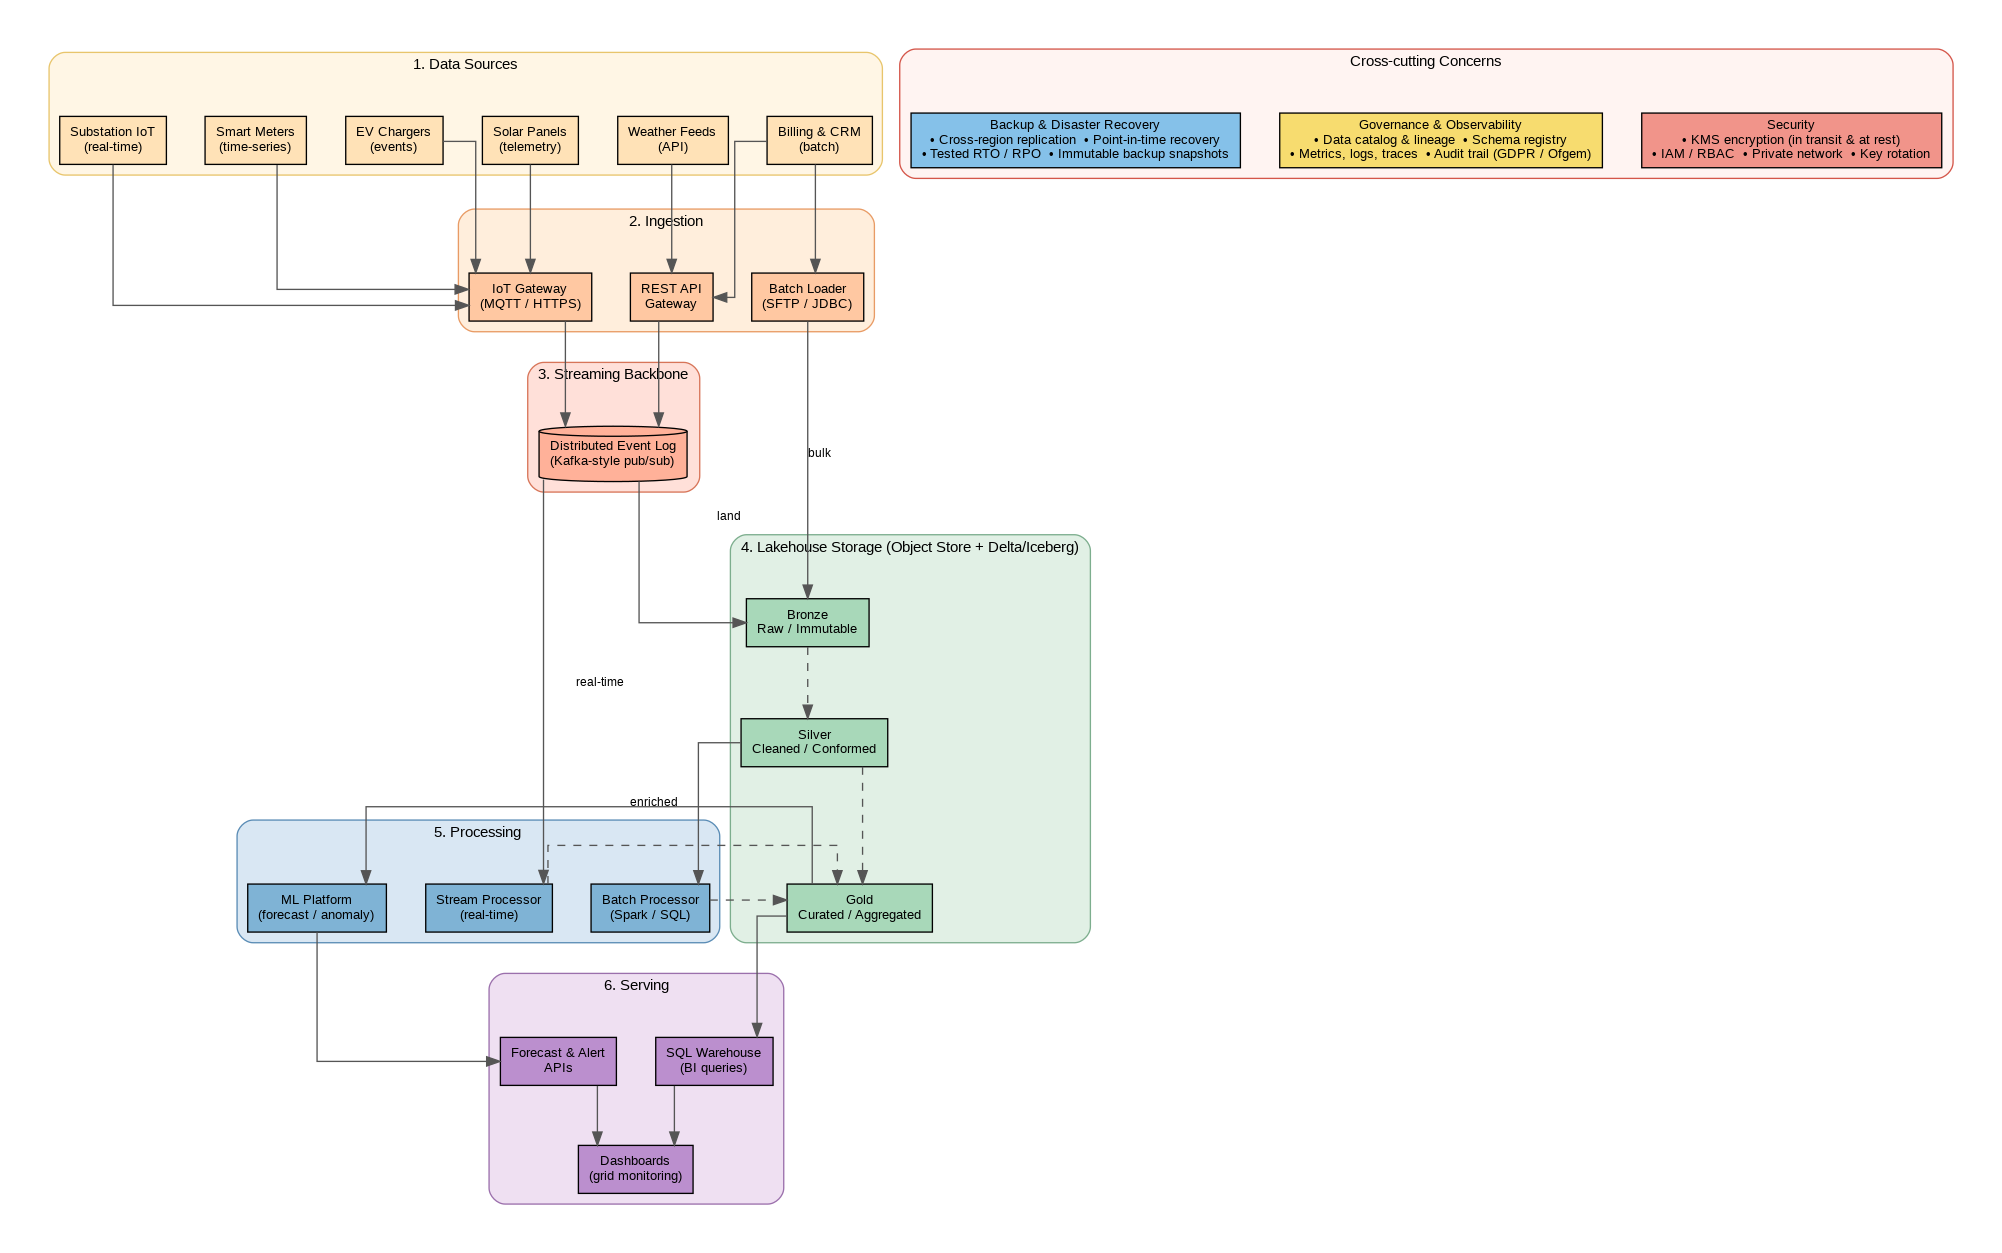

In [ ]:
from IPython.display import Image
Image('mes_architecture.png')

# Feature engineering and model training (excerpt)

In [ ]:
import pandas as pd
from sklearn.ensemble import RandomForestRegressor
import numpy as np

# Create a sample DataFrame 'df' for demonstration purposes
# In a real scenario, 'df' would be loaded from a dataset.
data_size = 24 * 60 # Enough data for 60 days to cover shifts and split
index = pd.date_range(start='2023-01-01', periods=data_size, freq='h') # Changed 'H' to 'h'
df = pd.DataFrame({
    'demand_mw': np.random.rand(data_size) * 100 + 50,
    'temperature_c': np.random.rand(data_size) * 20 + 10,
    'hour': index.hour,
    'dayofweek': index.dayofweek,
    'month': index.month
}, index=index)

# Feature engineering and model training (excerpt)
df['lag_1h']   = df['demand_mw'].shift(1)
df['lag_24h']  = df['demand_mw'].shift(24)
df['lag_168h'] = df['demand_mw'].shift(168)
df = df.dropna().reset_index(drop=True)

features = ['hour','dayofweek','month','temperature_c',
            'lag_1h','lag_24h','lag_168h']
split = len(df) - 24*30   # last 30 days as held-out test
X_tr, X_te = df[features].iloc[:split], df[features].iloc[split:]
y_tr, y_te = df['demand_mw'].iloc[:split], df['demand_mw'].iloc[split:]

model = RandomForestRegressor(n_estimators=120, max_depth=18,
                              random_state=42, n_jobs=-1)
model.fit(X_tr, y_tr)
pred = model.predict(X_te)

In [ ]:
import numpy as np
import pandas as pd

np.random.seed(42)  # so results are reproducible

# Generate 2 years of hourly timestamps
n_days = 730
hours = pd.date_range('2023-01-01', periods=n_days * 24, freq='h')

df = pd.DataFrame({'timestamp': hours})
df['hour']      = df['timestamp'].dt.hour
df['dayofweek'] = df['timestamp'].dt.dayofweek
df['month']     = df['timestamp'].dt.month
df['dayofyear'] = df['timestamp'].dt.dayofyear

# Build realistic UK-style demand from patterns + noise
BASE     = 32000
seasonal = 8000 * np.cos(2 * np.pi * (df['dayofyear'] - 15) / 365.25)
daily    = 5500 * np.sin(2 * np.pi * (df['hour'] - 6) / 24) + \
           3000 * np.exp(-((df['hour'] - 18) ** 2) / 12)
weekly   = np.where(df['dayofweek'] >= 5, -2500, 0)
temp     = 10 - 12 * np.cos(2 * np.pi * (df['dayofyear'] - 15) / 365.25) + \
           np.random.normal(0, 3, len(df))
weather  = -350 * (temp - 10)
noise    = np.random.normal(0, 600, len(df))

df['demand_mw']     = BASE + seasonal + daily + weekly + weather + noise
df['temperature_c'] = temp

print(f'Dataset ready: {len(df):,} hourly readings')

Dataset ready: 17,520 hourly readings


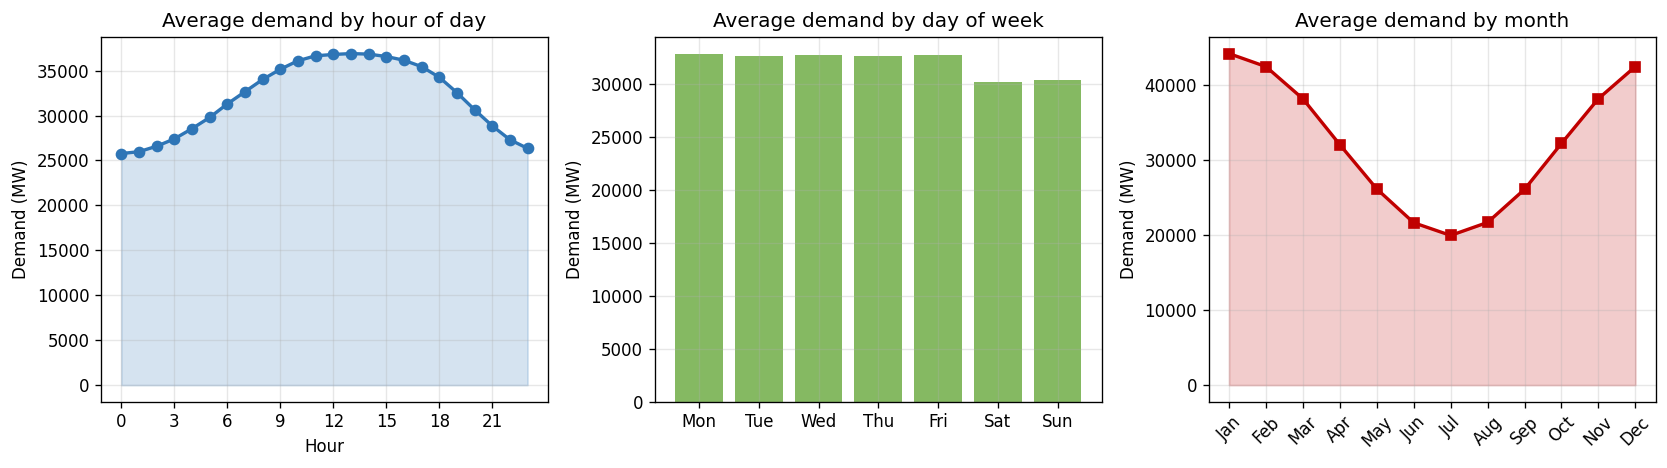

Figure 2 saved as poc_eda.png


In [ ]:
import matplotlib.pyplot as plt

# Set consistent chart styling
plt.rcParams.update({
    "figure.dpi": 120, "savefig.dpi": 150,
    "font.family": "DejaVu Sans", "font.size": 10,
    "axes.grid": True, "grid.alpha": 0.3,
})

# Create a figure with 3 side-by-side subplots (1 row, 3 columns)
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# --- Left panel: average demand by HOUR of day ---
hourly_avg = df.groupby('hour')['demand_mw'].mean()
axes[0].plot(hourly_avg.index, hourly_avg.values, marker='o', color='#2E75B6', lw=2)
axes[0].fill_between(hourly_avg.index, hourly_avg.values, alpha=0.2, color='#2E75B6')
axes[0].set_title('Average demand by hour of day')
axes[0].set_xlabel('Hour')
axes[0].set_ylabel('Demand (MW)')
axes[0].set_xticks(range(0, 24, 3))

# --- Middle panel: average demand by DAY OF WEEK ---
days = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
weekly_avg = df.groupby('dayofweek')['demand_mw'].mean()
axes[1].bar(days, weekly_avg.values, color='#70AD47', alpha=0.85)
axes[1].set_title('Average demand by day of week')
axes[1].set_ylabel('Demand (MW)')

# --- Right panel: average demand by MONTH ---
months = ['Jan','Feb','Mar','Apr','May','Jun',
          'Jul','Aug','Sep','Oct','Nov','Dec']
monthly_avg = df.groupby('month')['demand_mw'].mean()
axes[2].plot(months, monthly_avg.values, marker='s', color='#C00000', lw=2)
axes[2].fill_between(months, monthly_avg.values, alpha=0.2, color='#C00000')
axes[2].set_title('Average demand by month')
axes[2].set_ylabel('Demand (MW)')
axes[2].tick_params(axis='x', rotation=45)

# Tidy layout and save the file
plt.tight_layout()
plt.savefig('poc_eda.png', bbox_inches='tight')
plt.show()

print('Figure 2 saved as poc_eda.png')

In [ ]:
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error

# Feature engineering — create lag features
df['lag_1h']   = df['demand_mw'].shift(1)
df['lag_24h']  = df['demand_mw'].shift(24)
df['lag_168h'] = df['demand_mw'].shift(168)  # 1 week
df = df.dropna().reset_index(drop=True)

# The 7 features the model will use
features = ['hour', 'dayofweek', 'month', 'temperature_c',
            'lag_1h', 'lag_24h', 'lag_168h']

# Split: last 30 days as held-out test
split_idx = len(df) - 24 * 30
X_train, X_test = df[features].iloc[:split_idx], df[features].iloc[split_idx:]
y_train, y_test = df['demand_mw'].iloc[:split_idx], df['demand_mw'].iloc[split_idx:]
ts_test = df['timestamp'].iloc[split_idx:]

# Train the model
model = RandomForestRegressor(n_estimators=120, max_depth=18,
                              random_state=42, n_jobs=-1)
model.fit(X_train, y_train)
preds = model.predict(X_test)

# Compute metrics
mae  = mean_absolute_error(y_test, preds)
mape = mean_absolute_percentage_error(y_test, preds) * 100
rmse = np.sqrt(((preds - y_test) ** 2).mean())

print(f'MAE  : {mae:.1f} MW')
print(f'MAPE : {mape:.2f}%')
print(f'RMSE : {rmse:.1f} MW')

MAE  : 770.4 MW
MAPE : 1.84%
RMSE : 979.5 MW


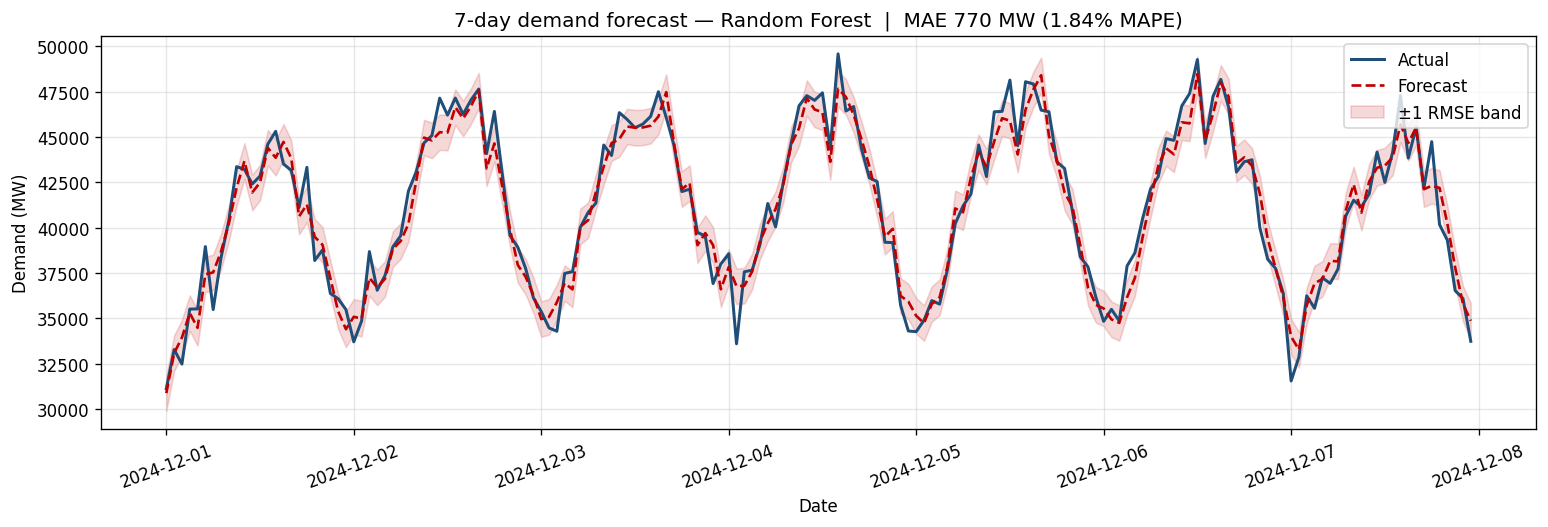

Figure 3 saved as poc_forecast.png


In [ ]:
import matplotlib.pyplot as plt

# Chart styling
plt.rcParams.update({
    "figure.dpi": 120, "savefig.dpi": 150,
    "font.family": "DejaVu Sans", "font.size": 10,
    "axes.grid": True, "grid.alpha": 0.3,
})

# Create the figure (single wide chart)
fig, ax = plt.subplots(figsize=(13, 4.5))

# The window: first 7 days of the test period = 168 hours
window = 24 * 7

# --- Plot 1: actual demand (solid blue line) ---
ax.plot(ts_test.iloc[:window],
        y_test.iloc[:window].values,
        label='Actual',
        color='#1F4E79',
        lw=1.8)

# --- Plot 2: forecast (dashed red line) ---
ax.plot(ts_test.iloc[:window],
        preds[:window],
        label='Forecast',
        color='#C00000',
        lw=1.6,
        linestyle='--')

# --- Plot 3: shaded uncertainty band around the forecast (±1 RMSE) ---
ax.fill_between(ts_test.iloc[:window],
                preds[:window] - rmse,
                preds[:window] + rmse,
                alpha=0.15,
                color='#C00000',
                label='±1 RMSE band')

# Titles and labels
ax.set_title(
    f'7-day demand forecast — Random Forest  |  '
    f'MAE {mae:.0f} MW ({mape:.2f}% MAPE)'
)
ax.set_xlabel('Date')
ax.set_ylabel('Demand (MW)')
ax.legend(loc='upper right')

# Rotate x-axis dates slightly so they don't overlap
plt.xticks(rotation=20)

# Tidy layout and save
plt.tight_layout()
plt.savefig('poc_forecast.png', bbox_inches='tight')
plt.show()

print('Figure 3 saved as poc_forecast.png')

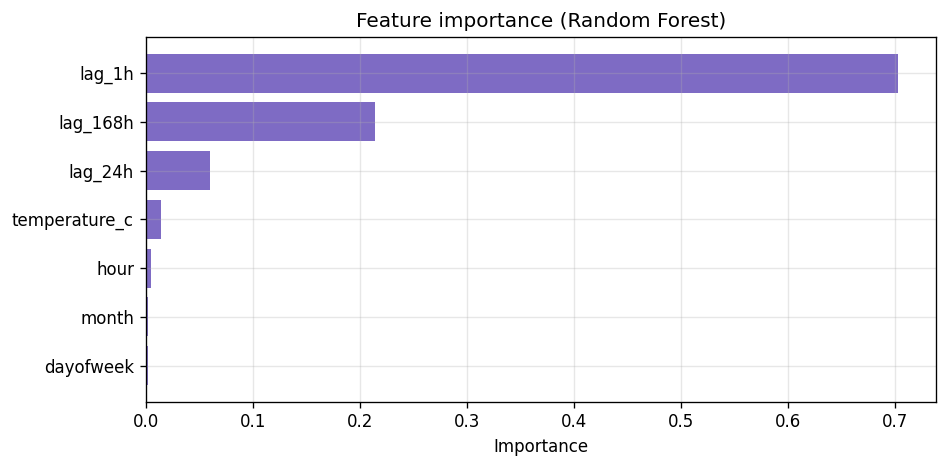

Figure 4 saved as poc_feature_importance.png


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Chart styling
plt.rcParams.update({
    "figure.dpi": 120, "savefig.dpi": 150,
    "font.family": "DejaVu Sans", "font.size": 10,
    "axes.grid": True, "grid.alpha": 0.3,
})

# Create the figure (single horizontal bar chart)
fig, ax = plt.subplots(figsize=(8, 4))

# --- Extract feature importances from the trained model ---
fi = pd.Series(model.feature_importances_, index=features).sort_values()

# --- Plot as a horizontal bar chart ---
ax.barh(fi.index, fi.values, color='#7E6BC4')

# Title and axis labels
ax.set_title('Feature importance (Random Forest)')
ax.set_xlabel('Importance')

# Tidy layout and save
plt.tight_layout()
plt.savefig('poc_feature_importance.png', bbox_inches='tight')
plt.show()

print('Figure 4 saved as poc_feature_importance.png')